# Lecture 04 — Student pass prediction

**Module:** OMC9000UK7 · Principles and Applications of Artificial Intelligence and Machine Learning  
**Programme:** MSc AI and Machine Learning · Gulf College  
**Lecture:** 04 — Introduction to Machine Learning and Data Mining  
**Topic:** Classification · **Learning outcome emphasis:** MLO1 and MLO3 (with MLO4 preparation through technique selection)

## Learning objective
Train an interpretable model to estimate pass/fail probability from synthetic learning indicators.

## Practical problem
A fictional module uses attendance, assignment score, study time and midterm results to estimate the probability of passing, so teaching staff can discuss timely support—not automatic academic decisions.

## Dataset and transparency
The file **`dataset.csv`** was simulated for teaching. It is not collected from real people, businesses, medical systems or physical devices. Names/values are illustrative; models must not be deployed or used for real eligibility, employment, financial, clinical or safety decisions. A fixed random seed makes the example reproducible.

**How to run:** keep this notebook and `dataset.csv` in the same folder, then run all cells from top to bottom. If needed, install the packages listed in the collection’s `requirements.txt`.

**Assumptions:** Performance patterns and outcomes are generated from artificial rules. Predictions should never be used for actual student grading or intervention without validation.

## 1. Load the dataset and understand the variables
Always inspect several rows, column names, types, and possible missing values before choosing a model.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (7.2, 4.5), 'axes.grid': True, 'grid.alpha': .22})
DATA_FILE = Path('dataset.csv')
assert DATA_FILE.exists(), 'Place dataset.csv next to the notebook.'
df = pd.read_csv(DATA_FILE)
print(f'Dataset: {len(df):,} rows × {df.shape[1]} columns')
display(df.head())

Dataset: 750 rows × 5 columns


,attendance_percent,assignment_score,study_hours_week,midterm_score,passed
0,33.8,23.4,22.7,19.2,0
1,86.9,26.5,7.6,60.3,1
2,34.4,95.5,11.8,54.9,0
3,86.6,37.1,20.9,56.5,0
4,45.3,79.5,14.0,56.6,0


In [2]:
print('Columns:', df.columns.tolist())
print('Missing values per column:')
print(df.isna().sum().to_string())

Columns: ['attendance_percent', 'assignment_score', 'study_hours_week', 'midterm_score', 'passed']
Missing values per column:
attendance_percent    0
assignment_score      0
study_hours_week      0
midterm_score         0
passed                0


## 2. Visualise and formulate the task
**Question:** Which available columns are inputs (features), and which column is the class label? A classification problem predicts a *category*, not a continuous number.

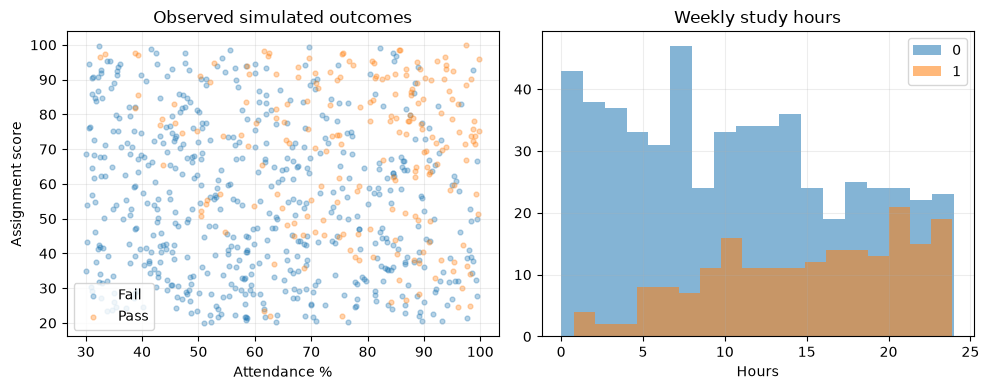

In [3]:
fig,ax=plt.subplots(1,2,figsize=(10,4))
for val,lab in [(0,'Fail'),(1,'Pass')]:
    subset=df[df['passed']==val];ax[0].scatter(subset['attendance_percent'],subset['assignment_score'],s=12,alpha=.32,label=lab)
ax[0].legend();ax[0].set(xlabel='Attendance %',ylabel='Assignment score',title='Observed simulated outcomes')
df.groupby('passed')['study_hours_week'].hist(ax=ax[1],alpha=.55,bins=18,legend=True)
ax[1].set(title='Weekly study hours',xlabel='Hours');plt.tight_layout();plt.show()

## 3. Prepare training and test data
The training set teaches the model. The test set simulates **unseen** examples. Split before fitting preprocessing transformations to avoid data leakage.

In [4]:
from sklearn.model_selection import train_test_split
X = df[['attendance_percent', 'assignment_score', 'study_hours_week', 'midterm_score']]
y = df['passed']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=42, stratify=y)
print('Train:', len(X_train), 'Test:', len(X_test)); print(y.value_counts())

Train: 562 Test: 188
passed
0    551
1    199
Name: count, dtype: int64


## 4. Train the selected algorithm
**Logistic regression** produces a probability for a binary outcome, with inputs standardised so large-number features do not dominate optimisation.

In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
model=make_pipeline(StandardScaler(),LogisticRegression(max_iter=1000,random_state=42))
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['attendance_percent','assignment_score','study_hours_week', 'midterm_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## 5. Evaluate the classifier
**Accuracy** is the share of correct predictions; **precision** asks how often predicted members of a class truly belong to it; **recall** asks how many true members are found. For multiclass examples we also report macro averages. The **confusion matrix** shows which categories are being mixed up.

Accuracy: 0.835
Precision (macro): 0.811
Recall (macro): 0.741
F1 (macro): 0.764
              precision    recall  f1-score   support

           0       0.85      0.94      0.89       138
           1       0.77      0.54      0.64        50

    accuracy                           0.84       188
   macro avg       0.81      0.74      0.76       188
weighted avg       0.83      0.84      0.82       188



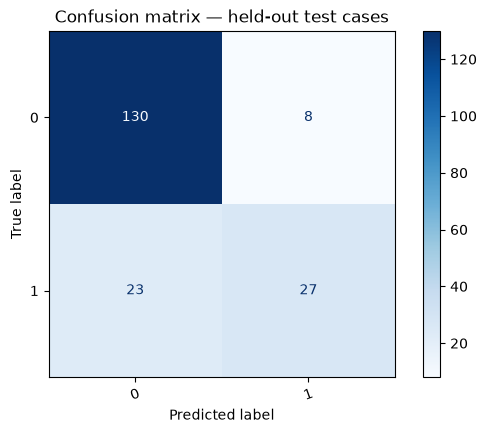

In [6]:
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay
print('Accuracy:', round(accuracy_score(y_test,y_pred),3))
print('Precision (macro):',round(precision_score(y_test,y_pred,average='macro',zero_division=0),3))
print('Recall (macro):',round(recall_score(y_test,y_pred,average='macro',zero_division=0),3))
print('F1 (macro):',round(f1_score(y_test,y_pred,average='macro',zero_division=0),3))
print(classification_report(y_test,y_pred,zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,cmap='Blues',xticks_rotation=20)
plt.title('Confusion matrix — held-out test cases'); plt.grid(False); plt.show()

## 6. Make predictions on new, unseen inputs
These are intentionally invented examples. Interpret the output as a demonstration of how a trained model is used, **not** a real-world recommendation.

In [7]:
new_students=pd.DataFrame([{'attendance_percent':93,'assignment_score':85,'study_hours_week':13,'midterm_score':82},{'attendance_percent':48,'assignment_score':42,'study_hours_week':3,'midterm_score':38},{'attendance_percent':75,'assignment_score':65,'study_hours_week':10,'midterm_score':64}])
new_students['predicted_pass']=model.predict(new_students)
new_students['estimated_pass_probability']=model.predict_proba(new_students[X.columns])[:,1].round(3)
display(new_students)

,attendance_percent,assignment_score,study_hours_week,midterm_score,predicted_pass,estimated_pass_probability
0,93,85,13,82,1,0.905
1,48,42,3,38,0,0.009
2,75,65,10,64,0,0.365


## Student investigation and discussion
1. What does a false negative mean in a student-support context?
2. Should attendance alone determine pass/fail? Explain.
3. Why must final grade components not leak into predictions made before the final exam?

**Reflect:** What assumption makes this classroom dataset easier than the equivalent real-world problem?

## References and further learning
- Russell, S. J., & Norvig, P. (2021). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.
- Mitchell, T. M. (1997). *Machine Learning*. McGraw-Hill.
- scikit-learn User Guide: https://scikit-learn.org/stable/user_guide.html
- Course connection: Lecture 04, OMC9000UK7, supervised/unsupervised learning, modelling workflow and evaluation.